# Gaia AI — Exploratory Data Analysis

Synthetic dataset of persona-conditioned WhatsApp users (hidden style seeds). We inspect class balance across style axes, message/target lengths, and pairs per user.

In [1]:
import json, statistics as st
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
ROOT = Path.cwd()
while not (ROOT/'ml'/'data'/'synthetic').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SYN = ROOT/'ml'/'data'/'synthetic'
def load(n):
    p = SYN/n
    return [json.loads(l) for l in p.read_text(encoding='utf-8').splitlines() if l.strip()] if p.exists() else []
personas, histories, pairs = load('personas.jsonl'), load('histories.jsonl'), load('pairs.jsonl')
len(personas), len(histories), len(pairs)

(30, 22, 170)

## 1. Dataset size

In [2]:
print(f'personas : {len(personas)}')
print(f'histories: {len(histories)}')
print(f'pairs    : {len(pairs)}')

personas : 30
histories: 22
pairs    : 170


## 2. Style-axis distributions (the diversity matrix)

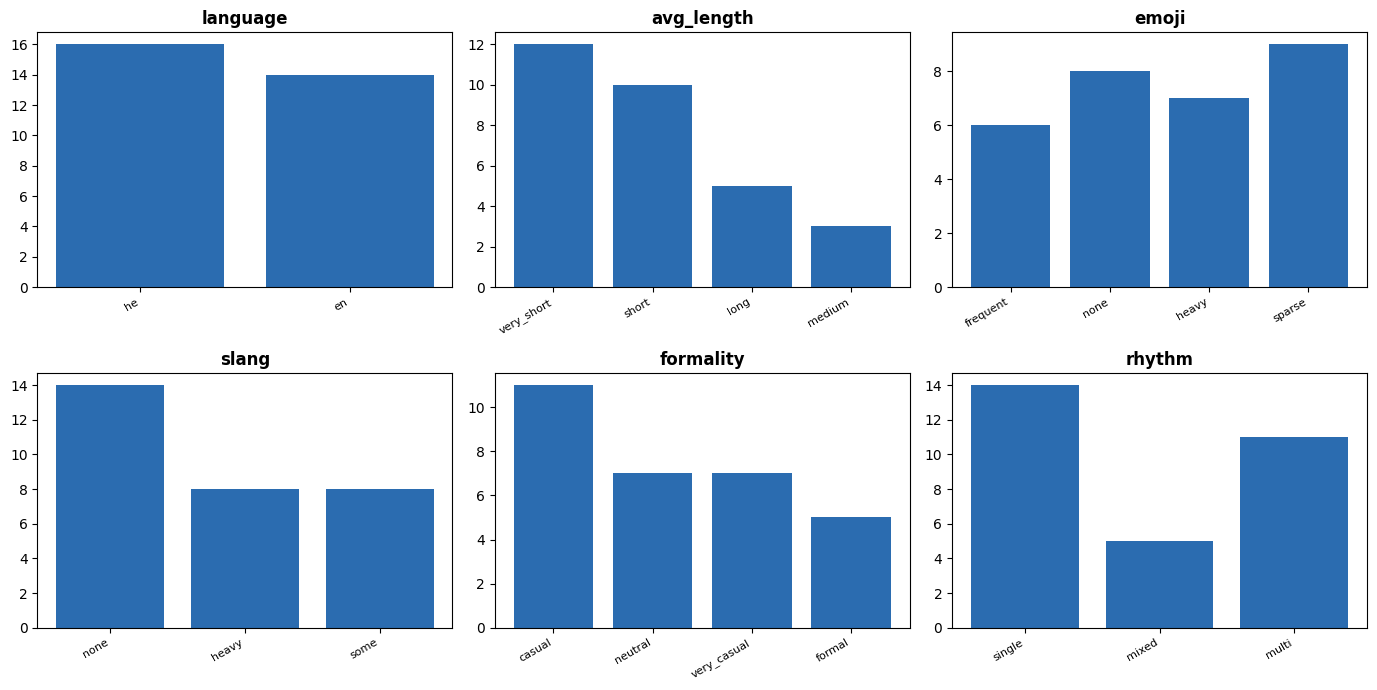

In [3]:
axes = ['language','avg_length','emoji','slang','formality','rhythm']
counts = {a: Counter() for a in axes}
for p in personas:
    hs = p.get('hidden_style', {})
    for a in axes:
        if hs.get(a) is not None: counts[a][hs[a]] += 1
fig, axx = plt.subplots(2, 3, figsize=(14, 7))
for ax, a in zip(axx.ravel(), axes):
    c = counts[a]; ax.bar(range(len(c)), list(c.values()), color='#2b6cb0')
    ax.set_xticks(range(len(c))); ax.set_xticklabels(list(c.keys()), rotation=30, ha='right', fontsize=8)
    ax.set_title(a, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Message & target-reply length distributions

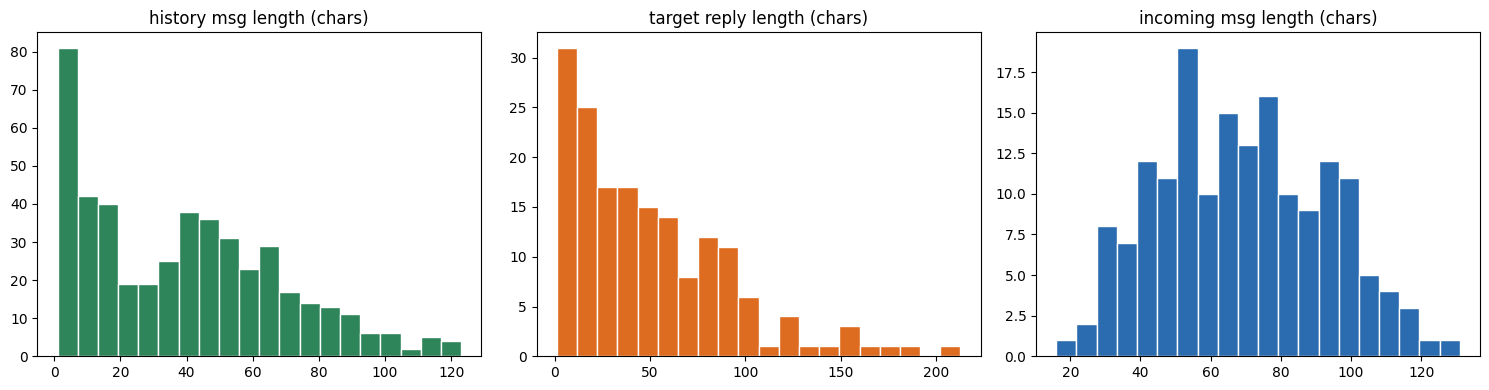

target len mean/median: 50.2 41.0


In [4]:
hist_lens = [len(m) for h in histories for m in h.get('messages', [])]
tgt_lens  = [len(p.get('target_response','')) for p in pairs]
inc_lens  = [len(p.get('incoming_message','')) for p in pairs]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(hist_lens, bins=20, color='#2f855a', edgecolor='white'); ax[0].set_title('history msg length (chars)')
ax[1].hist(tgt_lens, bins=20, color='#dd6b20', edgecolor='white'); ax[1].set_title('target reply length (chars)')
ax[2].hist(inc_lens, bins=20, color='#2b6cb0', edgecolor='white'); ax[2].set_title('incoming msg length (chars)')
plt.tight_layout(); plt.show()
if tgt_lens: print('target len mean/median:', round(st.mean(tgt_lens),1), st.median(tgt_lens))

## 4. Pairs per user

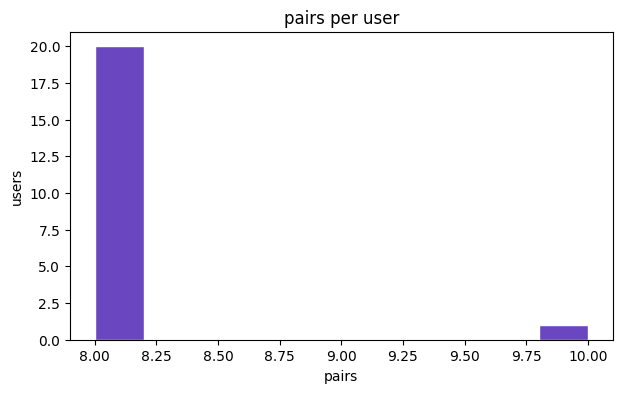

users with pairs: 21 | mean pairs/user: 8.1


In [5]:
per_user = Counter(p['user_id'] for p in pairs)
if per_user:
    plt.figure(figsize=(7,4)); plt.hist(list(per_user.values()), bins=10, color='#6b46c1', edgecolor='white')
    plt.title('pairs per user'); plt.xlabel('pairs'); plt.ylabel('users'); plt.show()
    print('users with pairs:', len(per_user), '| mean pairs/user:', round(st.mean(per_user.values()),1))

## Takeaways
- Style axes are spread across the diversity matrix (no single dominant class).
- Message and reply lengths skew short, matching real WhatsApp behavior.
- Static figures + a machine-readable `results/eda_stats.json` are produced by `ml/eda/run_eda.py`.